##### Change `sys.path.insert(0, '/home/dajiang/smart-pixels-ml/two_bit_optimization_helpers')` to **your** full path to `two_bit_optimization_helpers`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys
sys.path.insert(0, "/home/dajiang/smart-pixels-ml/two_bit_optimization_helpers") # Change this line to wherever the two_bit_optimization_helpers is located 
from prepare_tfrecords import load_tfrecords
from train import create_model, get_best_thresholds, cleanup_models_and_generators, get_all_losses, get_all_thresholds

2026-01-21 19:44:21.588184: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-21 19:44:22.251687: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Plot the Loss Curve for Part 1 or Part 2 Training
##### Arguments to change:
* `model_checkpoints` is the path to the directory containing all the saved models for each epoch.
##### Optional arguments to change:
* Any format/styling choices for matplotlib can be changed for your needs.

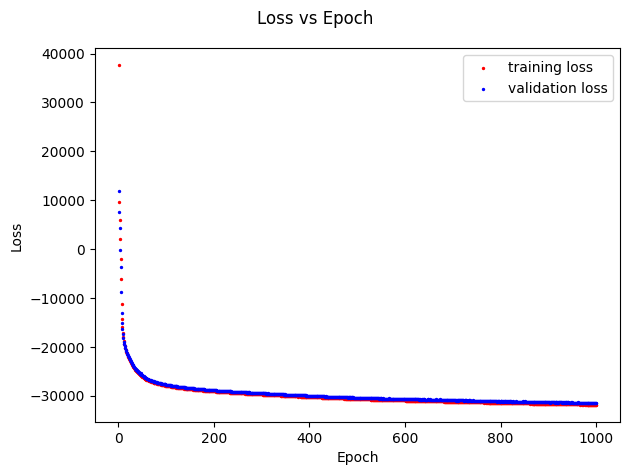

In [2]:
##### EXTRACT THE MODEL CHECKPOINTS ##################################################################################

model_checkpoints='/data/dajiang/smart-pixels/weights/dataset_3src_16x16_50x12P5_centeredIncidence_weights/weights-2t-Conv2D_Max-2bit_optimized-392456de-checkpoints'
train_losses, validation_losses = get_all_losses(f'{model_checkpoints}')
epochs = np.arange(1, len(train_losses)+1, 1)
#####################################################################################################################


##### PLOT THE MODEL CHECKPOINTS ###################################################################################
fig, ax = plt.subplots()
ax.scatter(x=epochs, y=train_losses, s=2, c='red', label='training loss')
ax.scatter(x=epochs, y=validation_losses, s=2, c='blue', label='validation loss')
ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend()
fig.suptitle(f'Loss vs Epoch')
fig.tight_layout()
# fig.savefig([INSERT FILEPATH TO WHERE YOU WANT TO SAVE THE PLOT], dpi=300)
fig.show()
####################################################################################################################

### Extract the best thresholds from Part 1 Training to plot the threshold optimization curve for Part 1 
##### Arguments to change:
* `input_dir` is the path to the directory containing all the saved models for each epoch.
* `model_type` is the corresponding model type.
##### Optional arguments to change:
* `threshold_offset` is set to 80.0 (default). If you didn't set it to 80.0 in the trainings, please change to what was the offset set in the training.
* `initial_levels` is set to 0.0, 1.0, 2.0, and 3.0 (default). If this was not used in the trainings, please change to what was set in the training.
* `timeslices` should always be set to 2, unless much of the training notebook was changed to allow for 20-timeslices trainings.
* Any format/styling choices for matplotlib can be changed for your needs.

In [3]:
thresholds_1, thresholds_2, thresholds_3 = get_all_thresholds(
    input_dir='/data/dajiang/smart-pixels/weights/dataset_3src_16x16_50x12P5_centeredIncidence_weights/weights-2t-Conv2D_Max-soft_quantize_layer-392456de-checkpoints',
    model_type='Conv2D_Max',
    threshold_offset=80.0,
    initial_levels=np.array([0.0, 1.0, 2.0, 3.0]),
    timeslices=2,
)

2026-01-21 19:44:24.341051: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3209 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB MIG 1g.5gb, pci bus id: 0000:01:00.0, compute capability: 8.0
100%|██████████| 1000/1000 [00:08<00:00, 121.44it/s]


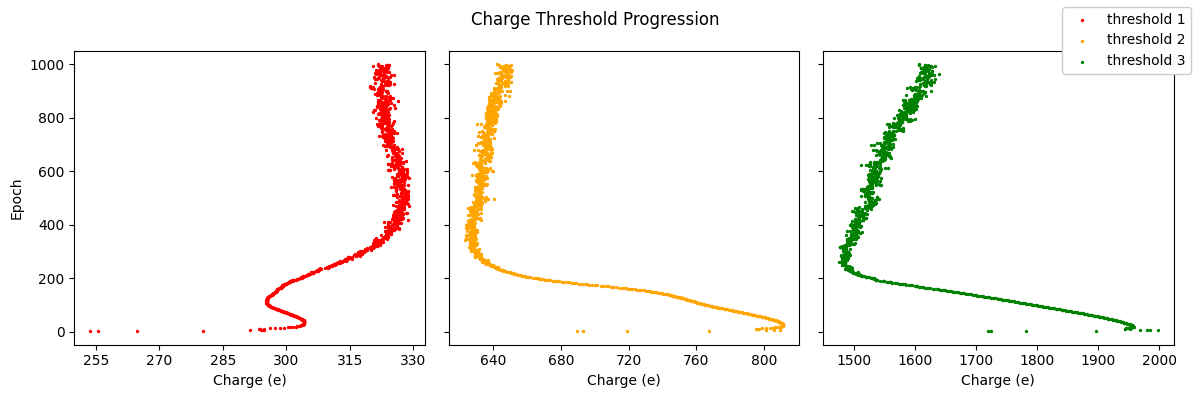

In [4]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
epochs=np.arange(1,len(thresholds_1)+1,1)
ax[0].scatter(x=thresholds_1, y=epochs, s=2, c='red', label='threshold 1')
ax[1].scatter(x=thresholds_2, y=epochs, s=2, c='orange', label='threshold 2')
ax[2].scatter(x=thresholds_3, y=epochs, s=2, c='green', label='threshold 3')

ax[0].set_ylabel('Epoch')

ax[0].set_xlabel('Charge (e)')
ax[1].set_xlabel('Charge (e)')
ax[2].set_xlabel('Charge (e)')

ax[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))
ax[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))
ax[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))

fig.legend(framealpha=1)
fig.suptitle(f'Charge Threshold Progression')
fig.tight_layout()
# fig.savefig([INSERT FILEPATH TO WHERE YOU WANT TO SAVE THE PLOT], dpi=300)
fig.show()

### Print out the best thresholds used to digitize inputs in Part 2 
##### Arguments to change:
* `input_dir` is the path to the directory containing all the saved models for each epoch.
* `model_type` is the corresponding model type.
##### Optional arguments to change:
* `threshold_offset` is set to 80.0 (default). If you didn't set it to 80.0 in the trainings, please change to what was the offset set in the training.
* `initial_levels` is set to 0.0, 1.0, 2.0, and 3.0 (default). If this was not used in the trainings, please change to what was set in the training.
* `timeslices` should always be set to 2, unless much of the training notebook was changed to allow for 20-timeslices trainings.
* Any format/styling choices for matplotlib can be changed for your needs.

In [5]:
thresholds, levels = get_best_thresholds(
    checkpoints='/data/dajiang/smart-pixels/weights/dataset_3src_16x16_50x12P5_centeredIncidence_weights/weights-2t-Conv2D_Max-soft_quantize_layer-392456de-checkpoints',
    model_type='Conv2D_Max',
    initial_thresholds=[247.8, 668.4, 1662.9],
    threshold_offset=80.0,
    initial_levels=np.array([0.0, 1.0, 2.0, 3.0]),
    timeslices=2,
)

Best model: weights.985-t-31718.17-v-31530.60.hdf5
---Soft Quantize Layer Details---
  Thresholds (e): [ 322.89075  646.3773  1610.1997 ]
  Levels: [0. 1. 2. 3.]
